# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 2 — Preprocessing: Grayscale + Resize + Median Filter + Histogram Equalization (4 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Import Library

### Fungsi
Cell ini mengimpor seluruh library yang diperlukan selama proses penelitian, mulai dari pengolahan citra digital, ekstraksi fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), visualisasi data, hingga proses klasifikasi menggunakan algoritma Machine Learning.

Library yang digunakan meliputi:

- **OpenCV (cv2)** untuk pengolahan citra digital.
- **NumPy** untuk komputasi numerik dan manipulasi array.
- **Pandas** untuk pengelolaan data tabular.
- **Matplotlib** untuk visualisasi data.
- **Scikit-image** untuk pembentukan matriks GLCM dan ekstraksi fitur tekstur.
- **Scikit-learn** untuk proses pembagian data, normalisasi, pelatihan model, dan evaluasi klasifikasi.

### Analisis
Tahap import library merupakan langkah awal yang penting karena seluruh proses pengolahan data dan klasifikasi bergantung pada fungsi-fungsi yang tersedia dalam library tersebut. Pemilihan library yang tepat dapat meningkatkan efisiensi komputasi, mempermudah implementasi algoritma, serta mendukung reproduktibilitas penelitian.

## Memuat Dataset dan Resize Citra

### Fungsi
Cell ini membaca seluruh citra ginjal dari dataset kemudian melakukan proses resize menjadi ukuran 256×256 piksel.

Selain itu, label kelas dan nama file citra juga disimpan untuk digunakan pada proses ekstraksi fitur dan klasifikasi.

### Analisis
Ukuran citra yang berbeda dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur. Oleh karena itu dilakukan resize agar seluruh citra memiliki dimensi yang seragam.

Ukuran 256×256 piksel dipilih karena mampu mempertahankan informasi tekstur yang cukup baik sekaligus menjaga efisiensi komputasi selama proses penelitian.

Output dari tahap ini berupa:

- Citra hasil resize.
- Label kelas.
- Nama file citra.

In [2]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (256, 256))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 648
Labels: ['Normal' 'kidneyStone']


## Visualisasi Distribusi Dataset

### Fungsi
Cell ini menampilkan distribusi jumlah citra pada masing-masing kelas menggunakan diagram batang (*bar chart*). Visualisasi ini digunakan untuk mengetahui komposisi dataset yang akan digunakan pada proses ekstraksi fitur GLCM dan klasifikasi.

### Analisis
Berdasarkan grafik distribusi dataset, diperoleh:

- Kelas **Normal** sebanyak **356 citra**
- Kelas **Kidney Stone** sebanyak **292 citra**

Sehingga total dataset yang digunakan dalam penelitian ini berjumlah **648 citra**.

Pemilihan jumlah data yang lebih banyak dilakukan karena pada percobaan awal menggunakan dataset yang lebih kecil, yaitu sekitar **100 citra untuk masing-masing kelas**, seluruh model klasifikasi mampu mencapai akurasi mendekati atau bahkan mencapai **100%**. Kondisi tersebut menunjukkan bahwa dataset terlalu mudah dipelajari oleh model sehingga perbedaan performa antar metode preprocessing maupun algoritma klasifikasi menjadi sulit diamati.

Oleh karena itu, jumlah data diperbesar agar variasi karakteristik citra yang dipelajari model menjadi lebih beragam. Dengan semakin banyak data yang digunakan, tingkat kompleksitas klasifikasi juga meningkat karena model harus mengenali lebih banyak variasi bentuk, tekstur, pencahayaan, dan karakteristik citra pada masing-masing kelas.

Meskipun jumlah data kelas Normal dan Kidney Stone tidak sama persis, perbedaannya masih relatif kecil sehingga distribusi dataset tetap dapat dianggap cukup seimbang. Kondisi ini memungkinkan model memperoleh representasi yang baik dari kedua kelas tanpa menimbulkan bias yang signifikan terhadap salah satu kelas.

Penggunaan dataset yang lebih besar diharapkan dapat menghasilkan evaluasi yang lebih realistis dan mampu menunjukkan pengaruh teknik preprocessing terhadap performa klasifikasi. Dengan demikian, perbandingan antara Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dapat dilakukan secara lebih objektif karena model diuji pada data yang lebih beragam dan menantang dibandingkan percobaan awal.

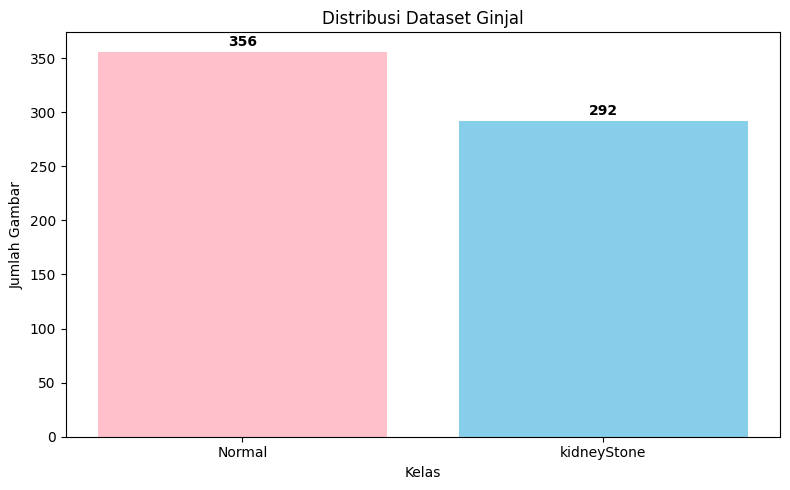

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Sampel Citra Dataset

### Fungsi
Cell ini menampilkan beberapa contoh citra dari setiap kelas yang terdapat pada dataset.

### Analisis
Visualisasi sampel citra bertujuan untuk melakukan pemeriksaan awal terhadap kualitas data serta memastikan bahwa proses pembacaan citra berjalan dengan benar.

Melalui tahap ini dapat diamati karakteristik visual yang membedakan ginjal normal dan ginjal batu sehingga peneliti memperoleh gambaran awal mengenai pola yang akan dipelajari oleh model klasifikasi.

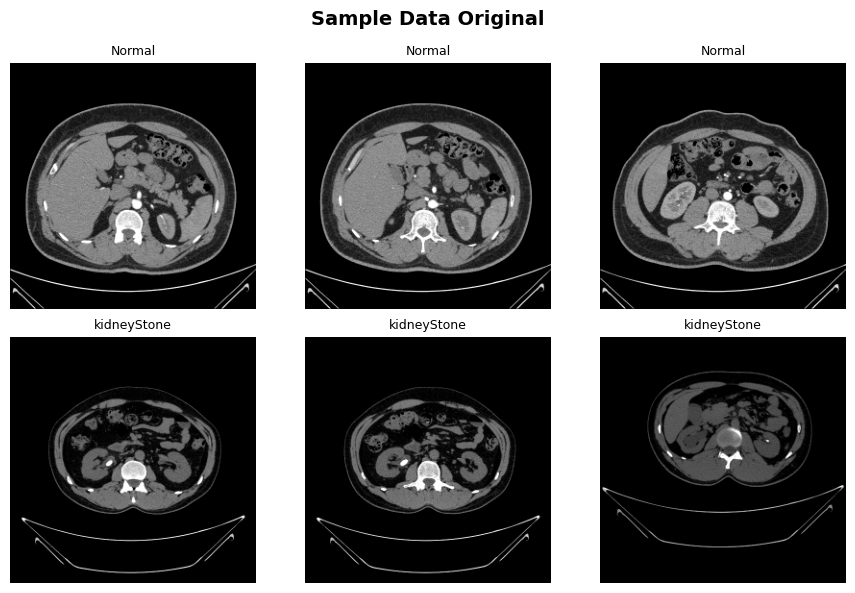

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Konversi Citra ke Grayscale

### Fungsi
Cell ini mengubah seluruh citra berwarna menjadi citra grayscale menggunakan fungsi konversi warna pada OpenCV.

Proses ini mengubah citra tiga kanal warna menjadi satu kanal intensitas keabuan.

### Analisis
Metode GLCM bekerja berdasarkan hubungan tingkat keabuan antar piksel sehingga informasi warna tidak diperlukan.

Konversi grayscale memberikan beberapa keuntungan, yaitu:

- Mengurangi kompleksitas data.
- Mempercepat proses komputasi.
- Menghilangkan informasi warna yang tidak relevan.
- Memfokuskan analisis pada karakteristik tekstur citra.

Output dari tahap ini berupa citra grayscale yang siap diproses pada tahap preprocessing berikutnya.

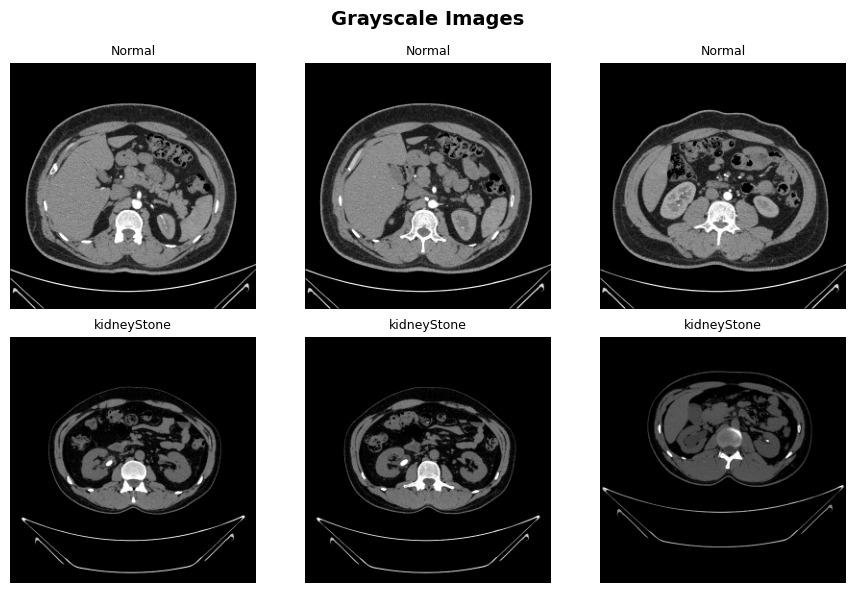

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Penerapan Median Filter

### Fungsi
Cell ini menerapkan teknik Median Filter pada seluruh citra grayscale.

Median Filter bekerja dengan mengganti nilai suatu piksel menggunakan nilai median dari piksel-piksel di sekitarnya berdasarkan ukuran kernel tertentu.

### Analisis
Tujuan utama penggunaan Median Filter adalah mengurangi noise tanpa merusak tepi objek pada citra.

Berbeda dengan metode smoothing lainnya, Median Filter mampu mempertahankan detail tekstur dan batas objek dengan lebih baik sehingga sangat sesuai digunakan pada citra medis.

Manfaat penggunaan Median Filter antara lain:

- Mengurangi noise impulsif (salt and pepper noise).
- Mempertahankan detail tepi objek.
- Meningkatkan kualitas citra sebelum ekstraksi fitur.
- Menghasilkan representasi tekstur yang lebih stabil.

Output dari tahap ini berupa citra grayscale yang telah mengalami reduksi noise.

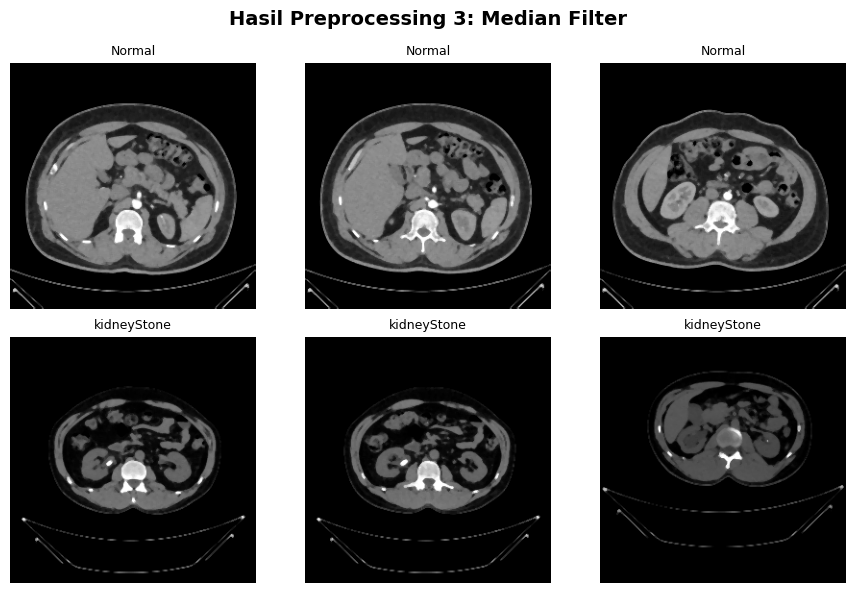

In [6]:
# Fungsi Median Filter
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

# Menerapkan Median Filter
img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Hasil Preprocessing 3: Median Filter')

## Penerapan Histogram Equalization

### Fungsi
Cell ini menerapkan teknik Histogram Equalization pada citra hasil Median Filter.

Histogram Equalization merupakan metode peningkatan kualitas citra yang bekerja dengan mendistribusikan ulang nilai intensitas piksel sehingga rentang kontras menjadi lebih luas.

### Analisis
Pada citra medis sering ditemukan perbedaan tingkat pencahayaan dan kontras yang dapat mempengaruhi kualitas fitur yang diekstraksi.

Histogram Equalization digunakan untuk:

- Meningkatkan kontras citra.
- Memperjelas detail tekstur.
- Mempertegas perbedaan area objek dan latar belakang.
- Meningkatkan kualitas fitur GLCM yang dihasilkan.

Dengan kontras yang lebih baik, pola tekstur pada citra ginjal menjadi lebih mudah dikenali oleh algoritma klasifikasi.

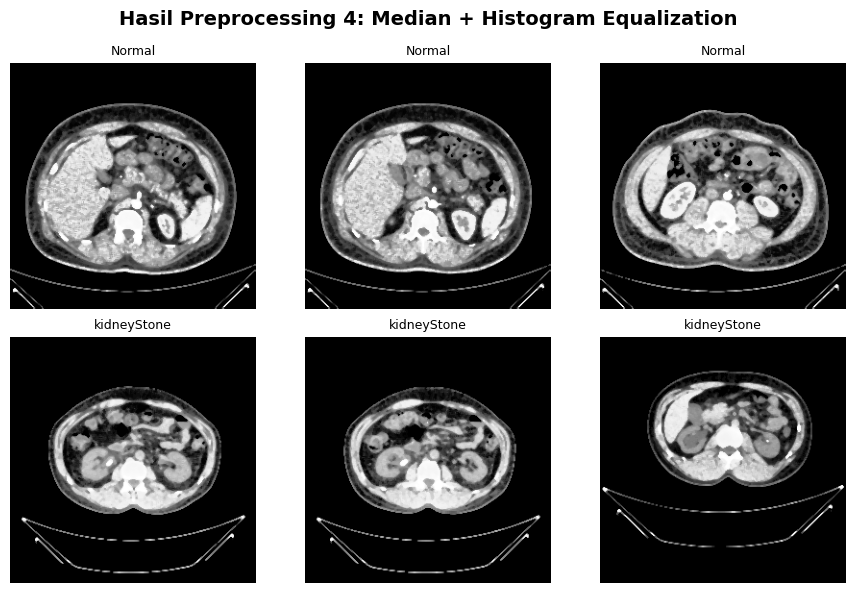

In [7]:
# Fungsi Histogram Equalization
def histogram_equalization(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[image]

# Menerapkan Histogram Equalization pada hasil median filter
dataPreprocessed = []
for img in img_median:
    equalized = histogram_equalization(img)
    dataPreprocessed.append(equalized)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 4: Median + Histogram Equalization')

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi GLCM dan Fitur Tekstur

### Fungsi
Cell ini mendefinisikan fungsi pembentukan matriks Gray Level Co-occurrence Matrix (GLCM) dan perhitungan fitur tekstur yang akan digunakan dalam proses klasifikasi.

Fitur yang diekstraksi meliputi:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- ASM

### Analisis
GLCM merupakan metode statistik orde kedua yang digunakan untuk menggambarkan hubungan spasial antar piksel pada citra.

Fitur-fitur yang dihasilkan mampu merepresentasikan karakteristik tekstur yang terdapat pada citra ginjal sehingga dapat digunakan sebagai masukan bagi algoritma Machine Learning.

## Pembentukan Matriks GLCM pada Berbagai Sudut

### Fungsi
Cell ini digunakan untuk membentuk matriks GLCM pada empat orientasi sudut, yaitu:

- 0°
- 45°
- 90°
- 135°

### Analisis
Setiap orientasi sudut merepresentasikan hubungan spasial piksel dari arah yang berbeda.

Penggunaan beberapa orientasi bertujuan untuk memperoleh informasi tekstur yang lebih lengkap sehingga pola yang terdapat pada citra dapat direpresentasikan secara lebih baik.

Pendekatan ini membantu meningkatkan kemampuan model dalam membedakan kelas ginjal normal dan batu ginjal.

In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 648 images


## Ekstraksi Fitur Tekstur GLCM

### Fungsi
Cell ini menghitung nilai fitur tekstur dari setiap matriks GLCM yang telah dibentuk sebelumnya.

### Analisis
Tahap ekstraksi fitur mengubah informasi visual pada citra menjadi representasi numerik yang dapat diproses oleh algoritma Machine Learning.

Fitur tekstur yang diperoleh diharapkan mampu menangkap perbedaan pola jaringan antara ginjal normal dan ginjal yang mengandung batu.

In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


## Pembentukan Dataset Fitur GLCM

### Fungsi
Cell ini menyusun seluruh fitur hasil ekstraksi Gray Level Co-occurrence Matrix (GLCM) ke dalam sebuah DataFrame menggunakan library Pandas.

Setiap baris merepresentasikan satu citra ginjal, sedangkan setiap kolom merepresentasikan fitur tekstur yang diperoleh dari proses ekstraksi GLCM pada berbagai orientasi sudut.

Dataset yang terbentuk terdiri dari informasi nama file, label kelas, serta fitur-fitur tekstur hasil ekstraksi GLCM yang akan digunakan pada proses klasifikasi.

### Analisis

Hasil ekstraksi menghasilkan dataset fitur tekstur yang terdiri dari citra kelas Normal dan Kidney Stone yang telah melalui proses Median Filter dan Histogram Equalization sebelum dilakukan ekstraksi fitur.

Median Filter digunakan untuk mengurangi noise pada citra tanpa merusak detail tepi objek, sedangkan Histogram Equalization digunakan untuk meningkatkan kontras sehingga pola tekstur menjadi lebih jelas.

Dengan kualitas citra yang lebih baik, fitur-fitur GLCM yang dihasilkan diharapkan mampu merepresentasikan karakteristik tekstur ginjal secara lebih akurat dibandingkan preprocessing pertama. Peningkatan kontras membantu memperjelas perbedaan intensitas antar piksel, sedangkan reduksi noise membantu mengurangi gangguan yang dapat mempengaruhi proses ekstraksi fitur.

Perbedaan nilai fitur antara kelas Normal dan Kidney Stone menunjukkan bahwa kombinasi Median Filter dan Histogram Equalization mampu mempertahankan bahkan memperjelas karakteristik tekstur yang membedakan kedua kelas tersebut.

Dataset fitur yang dihasilkan pada tahap ini menjadi representasi numerik dari citra yang telah mengalami peningkatan kualitas sehingga diharapkan dapat memberikan performa klasifikasi yang lebih baik dibandingkan penggunaan citra grayscale saja.

Output dari tahap ini berupa dataset fitur GLCM yang siap digunakan untuk proses seleksi fitur, normalisasi, dan klasifikasi.

In [11]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,397.135233,787.122676,564.396078,744.555479,0.620931,0.566666,0.611782,0.568510,...,0.226130,0.222961,0.479335,0.471604,0.475531,0.472187,0.971450,0.943496,0.959425,0.946551
1,10.jpg,Normal,409.753631,791.826759,559.887592,745.448689,0.621714,0.570290,0.615098,0.571514,...,0.229289,0.226113,0.482750,0.474884,0.478841,0.475514,0.970435,0.942951,0.959602,0.946293
2,100.jpg,Normal,410.373545,800.807366,585.145558,777.426113,0.645321,0.596054,0.634914,0.597266,...,0.260654,0.257334,0.514494,0.506695,0.510543,0.507281,0.969406,0.940398,0.956376,0.942138
3,11.jpg,Normal,410.351900,795.139177,560.983563,748.121107,0.619515,0.573123,0.617917,0.571592,...,0.229725,0.226522,0.483151,0.475333,0.479297,0.475943,0.970385,0.942700,0.959514,0.946088
4,12.jpg,Normal,410.760570,796.785113,565.145374,751.943345,0.623659,0.571168,0.616488,0.573180,...,0.229785,0.226608,0.483266,0.475521,0.479359,0.476034,0.970338,0.942547,0.959189,0.945780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Stone- (515).jpg,kidneyStone,419.781357,941.307389,750.077880,962.096993,0.656331,0.602071,0.640283,0.600489,...,0.258252,0.254582,0.512496,0.505177,0.508185,0.504561,0.968695,0.929910,0.944069,0.928362
644,Stone- (516).jpg,kidneyStone,422.796630,948.440292,760.065104,977.855932,0.656129,0.601391,0.641231,0.599563,...,0.257821,0.254100,0.511999,0.504704,0.507761,0.504083,0.968482,0.929403,0.943344,0.927214
645,Stone- (517).jpg,kidneyStone,431.989108,963.758247,778.195879,1002.867051,0.657311,0.601417,0.639832,0.598796,...,0.257256,0.253369,0.511365,0.504042,0.507204,0.503357,0.967797,0.928265,0.941994,0.925354
646,Stone- (518).jpg,kidneyStone,438.373361,978.413948,787.385110,1014.519723,0.657163,0.602342,0.642251,0.599354,...,0.256379,0.252448,0.510654,0.503294,0.506339,0.502442,0.967351,0.927239,0.941362,0.924554


## Seleksi Fitur Menggunakan Correlation Matrix

### Fungsi
Cell ini melakukan proses seleksi fitur menggunakan metode Correlation Matrix untuk mengidentifikasi dan menghapus fitur-fitur yang memiliki korelasi sangat tinggi.

Fitur yang memiliki nilai korelasi di atas ambang batas yang ditentukan dianggap membawa informasi yang serupa sehingga salah satunya dapat dihapus untuk mengurangi redundansi data.

### Hasil Seleksi Fitur

Berdasarkan proses seleksi diperoleh:

- Jumlah fitur sebelum seleksi : **28 fitur**
- Jumlah fitur setelah seleksi : **10 fitur**
- Jumlah fitur yang dihapus : **18 fitur**

Fitur yang terpilih adalah:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Dissimilarity0
- Dissimilarity45
- Dissimilarity90
- Entropy0
- Correlation0
- Correlation45

### Alasan Penggunaan Correlation Matrix

Pada hasil ekstraksi GLCM, beberapa fitur dapat memiliki korelasi yang sangat tinggi karena dihitung pada berbagai orientasi sudut dan menggambarkan pola tekstur yang serupa.

Seleksi fitur dilakukan untuk mempertahankan fitur yang paling representatif dan menghilangkan fitur yang memiliki informasi berulang.

### Analisis Hasil

Hasil seleksi menunjukkan bahwa jumlah fitur berkurang dari 28 menjadi 10 fitur. Menariknya, fitur yang bertahan sama seperti pada preprocessing pertama, yaitu Contrast, Homogeneity, Dissimilarity, Entropy, dan Correlation.

Meskipun demikian, preprocessing kedua telah menambahkan Median Filter dan Histogram Equalization sebelum ekstraksi fitur dilakukan. Median Filter berfungsi mengurangi noise pada citra, sedangkan Histogram Equalization meningkatkan kontras sehingga detail tekstur menjadi lebih jelas.

Karena kualitas citra meningkat, nilai fitur yang dihasilkan menjadi lebih stabil dan lebih mudah merepresentasikan karakteristik tekstur sebenarnya dari citra ginjal. Namun, pola hubungan antar fitur masih menunjukkan struktur yang serupa dengan preprocessing pertama sehingga kelompok fitur yang dipilih tetap sama.

Keberadaan fitur Contrast dan Dissimilarity menunjukkan bahwa variasi intensitas piksel masih menjadi faktor penting dalam membedakan kedua kelas. Fitur Homogeneity dan Correlation menunjukkan bahwa tingkat keseragaman tekstur dan hubungan spasial antar piksel juga berperan dalam proses klasifikasi. Sementara itu, Entropy tetap dipertahankan karena kompleksitas pola tekstur masih memberikan informasi yang relevan.

Hasil ini menunjukkan bahwa penambahan Median Filter dan Histogram Equalization lebih berpengaruh terhadap kualitas representasi fitur dibandingkan terhadap jenis fitur yang dipilih. Dengan kata lain, preprocessing kedua membantu memperjelas informasi tekstur tanpa mengubah karakteristik utama fitur yang dianggap paling penting oleh proses seleksi.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 10
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Entropy0', 'Correlation0', 'Correlation45']


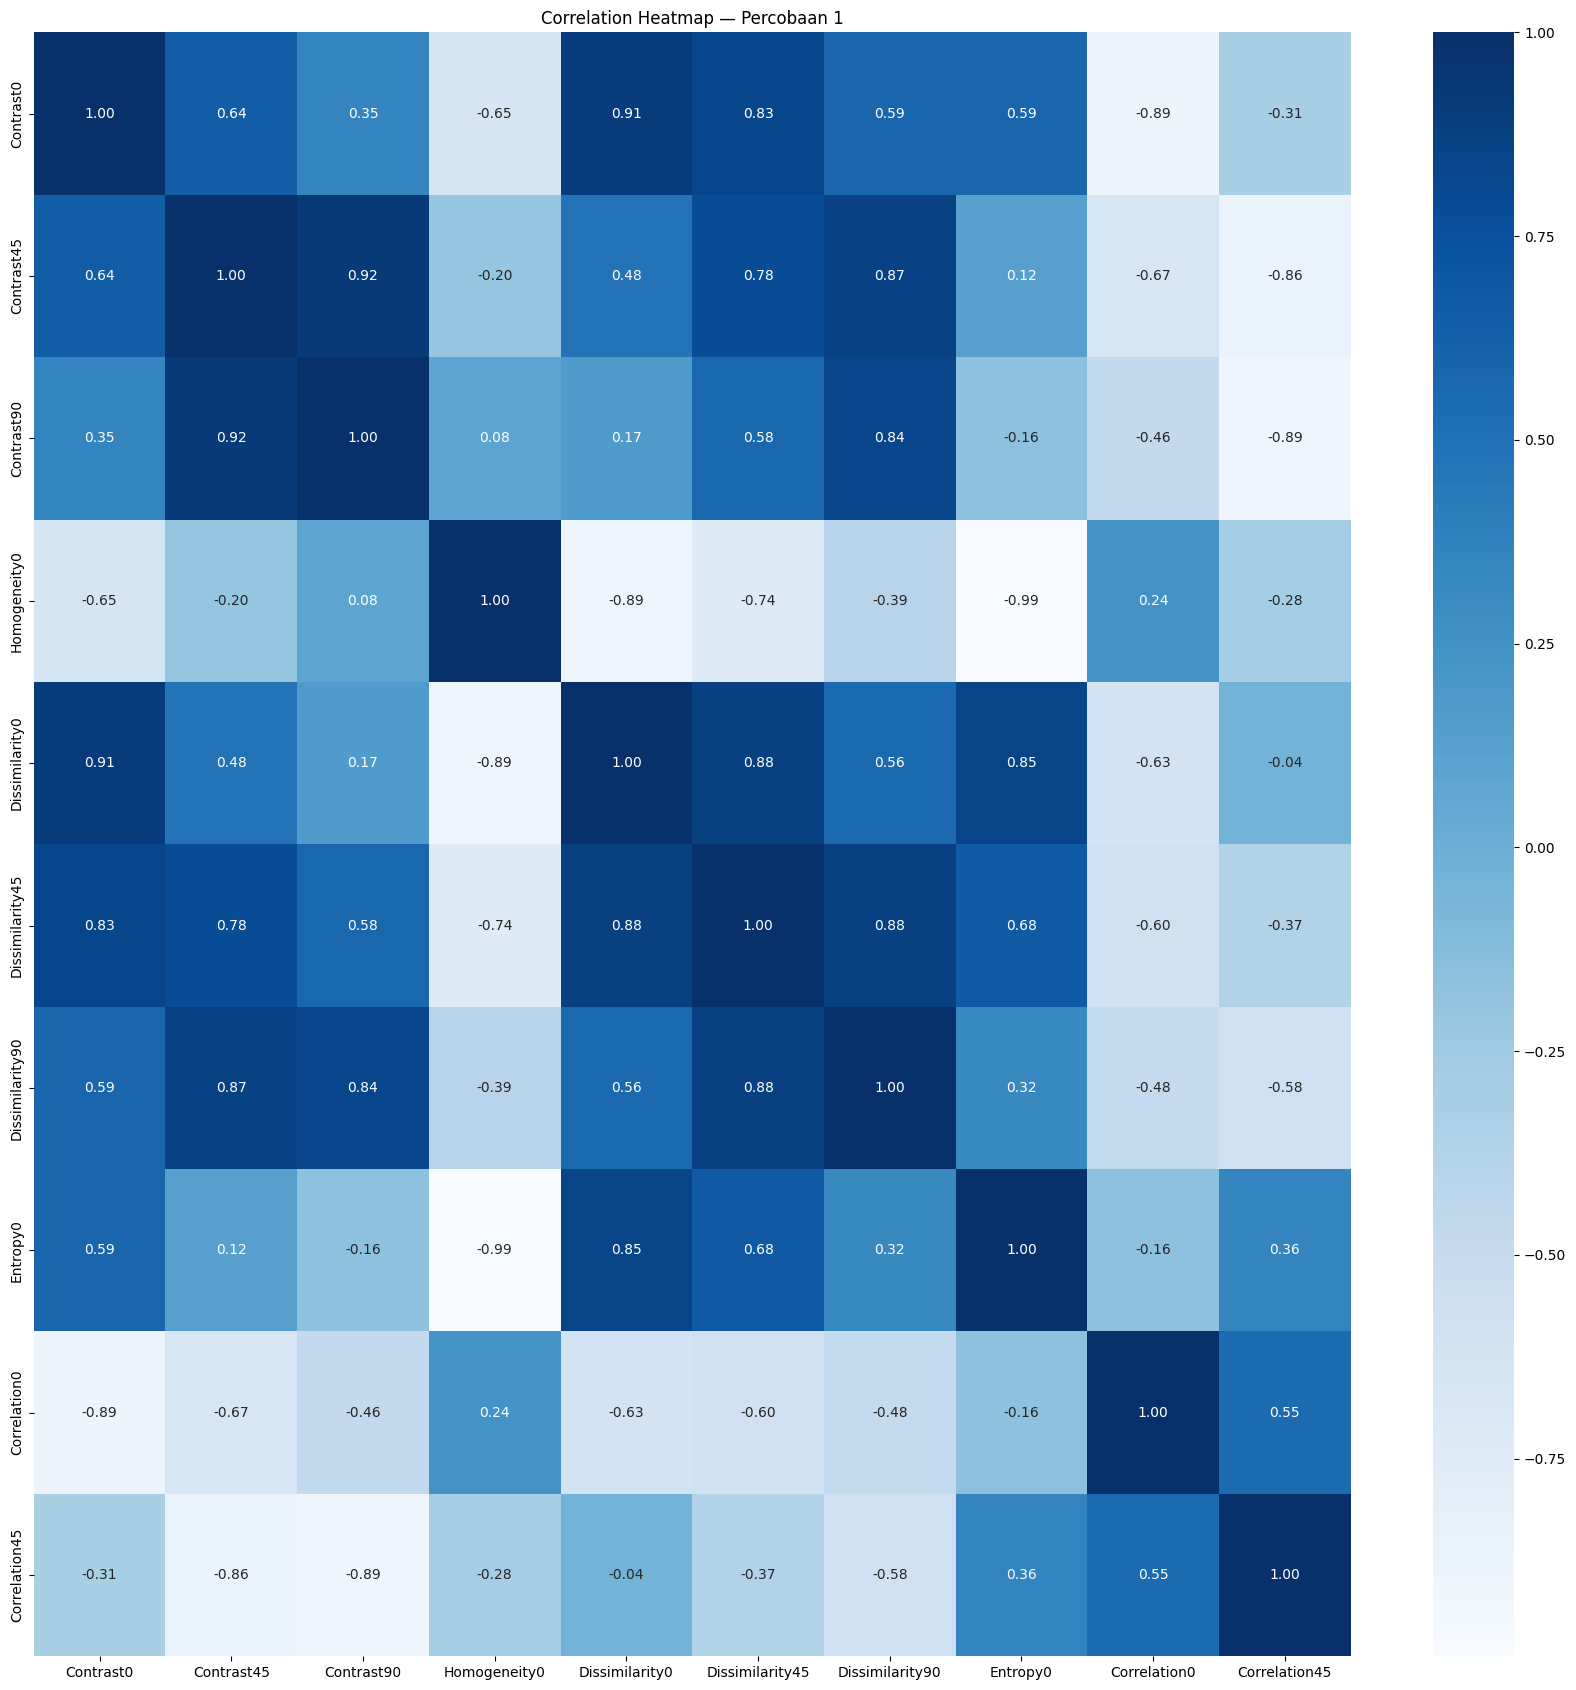

In [12]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Pembagian Data Training dan Testing

### Fungsi
Cell ini membagi dataset fitur hasil seleksi menjadi data training dan data testing menggunakan fungsi `train_test_split()` dari library Scikit-Learn.

Pembagian data dilakukan secara acak untuk memastikan bahwa setiap data memiliki peluang yang sama untuk masuk ke kelompok training maupun testing.

### Hasil Pembagian Data

Berdasarkan proses pembagian data diperoleh:

- Data Training : **388 data**
- Data Testing : **260 data**
- Total Data : **648 data**

Dengan jumlah fitur yang digunakan setelah proses seleksi sebanyak **10 fitur**.

Sehingga ukuran dataset yang dihasilkan adalah:

- Training set : **(388, 10)**
- Testing set : **(260, 10)**

Proporsi pembagian data yang digunakan adalah sekitar:

- **60% data training**
- **40% data testing**

### Analisis

Data training digunakan untuk melatih model klasifikasi agar dapat mempelajari pola hubungan antara fitur tekstur GLCM dan kelas citra ginjal. Sementara itu, data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang tidak digunakan selama proses pelatihan.

Pada penelitian ini, sebanyak 388 data digunakan sebagai data training dan 260 data digunakan sebagai data testing. Jumlah data testing yang relatif lebih besar dibandingkan skenario 80:20 memberikan proses evaluasi yang lebih ketat karena model diuji pada lebih banyak data yang belum pernah dilihat sebelumnya.

Penggunaan proporsi 60:40 memungkinkan evaluasi performa model dilakukan pada sampel yang lebih beragam sehingga hasil pengujian dapat memberikan gambaran yang lebih representatif mengenai kemampuan generalisasi model.

Pembagian data dilakukan menggunakan parameter `random_state` yang tetap sehingga hasil pembagian dapat direproduksi kembali pada percobaan selanjutnya. Selain itu, seluruh algoritma klasifikasi menggunakan data training dan testing yang sama sehingga perbandingan performa antar model dapat dilakukan secara objektif.

Tahap ini sangat penting karena memastikan bahwa hasil evaluasi yang diperoleh tidak hanya mencerminkan kemampuan model dalam menghafal data training, tetapi juga kemampuannya dalam mengenali pola pada data baru yang belum pernah dilihat sebelumnya.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.4, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (388, 10)
Testing set: (260, 10)


In [14]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data Fitur

### Fungsi
Cell ini melakukan normalisasi data menggunakan metode **Z-Score Standardization** atau **Standard Scaling**.

Normalisasi dilakukan dengan rumus:

\[
Z = \frac{x-\mu}{\sigma}
\]

dengan:

- \(x\) = nilai fitur
- \(\mu\) = rata-rata fitur pada data training
- \(\sigma\) = standar deviasi fitur pada data training

Pada proses ini, nilai rata-rata dan standar deviasi dihitung dari data training, kemudian digunakan untuk menormalisasi data training maupun data testing.

### Alasan Dilakukan Normalisasi

Fitur-fitur hasil ekstraksi GLCM memiliki rentang nilai yang berbeda-beda.

Sebagai contoh:

- Contrast dapat memiliki nilai hingga ribuan.
- Correlation umumnya berada pada rentang 0 hingga 1.
- Homogeneity biasanya memiliki nilai sekitar 0,4 hingga 0,8.

Perbedaan skala tersebut dapat menyebabkan fitur dengan nilai yang lebih besar mendominasi proses pembelajaran model.

Oleh karena itu dilakukan normalisasi agar seluruh fitur berada pada skala yang sebanding.

### Analisis

Setelah proses normalisasi, setiap fitur memiliki:

- Rata-rata (mean) mendekati 0.
- Standar deviasi (standard deviation) mendekati 1.

Proses ini membuat seluruh fitur memiliki kontribusi yang lebih seimbang selama proses klasifikasi.

Normalisasi menjadi sangat penting terutama pada algoritma:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

karena kedua algoritma tersebut menggunakan perhitungan jarak atau posisi data dalam ruang fitur. Apabila terdapat fitur dengan rentang nilai yang jauh lebih besar dibandingkan fitur lainnya, maka fitur tersebut dapat mendominasi proses klasifikasi dan menyebabkan hasil prediksi menjadi kurang optimal.

Pada penelitian ini, nilai rata-rata dan standar deviasi dihitung dari data training kemudian digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari terjadinya *data leakage*, yaitu kondisi ketika informasi dari data testing ikut digunakan selama proses pelatihan model.

Dengan demikian, proses evaluasi model dapat dilakukan secara lebih objektif dan mencerminkan kemampuan model dalam menghadapi data baru yang belum pernah dilihat sebelumnya.

In [15]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

### Fungsi

Cell ini mendefinisikan fungsi evaluasi serta menginisialisasi tiga algoritma klasifikasi yang akan digunakan dalam penelitian, yaitu:

1. Random Forest (RF)
2. Support Vector Machine (SVM)
3. K-Nearest Neighbor (KNN)

Selain itu, dibuat fungsi `generateClassificationReport()` untuk menampilkan hasil evaluasi model berupa:

- Precision
- Recall
- F1-Score
- Accuracy

Hasil evaluasi tersebut digunakan untuk membandingkan performa masing-masing algoritma dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

### Alasan Pemilihan Algoritma

Ketiga algoritma dipilih karena memiliki pendekatan klasifikasi yang berbeda sehingga dapat memberikan perbandingan performa yang lebih komprehensif terhadap fitur tekstur GLCM yang digunakan.

- Random Forest mewakili metode berbasis ensemble learning.
- SVM mewakili metode berbasis hyperplane.
- KNN mewakili metode berbasis kedekatan jarak antar data.

Dengan menggunakan ketiga algoritma tersebut, dapat diketahui algoritma mana yang paling efektif dalam mengenali pola tekstur citra ginjal.

### Parameter Model

#### Random Forest

```python
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
```

Parameter `n_estimators=100` menunjukkan bahwa model membangun 100 pohon keputusan (*decision tree*) yang kemudian digabungkan melalui mekanisme voting untuk menghasilkan keputusan akhir.

Jumlah 100 pohon dipilih karena secara umum mampu memberikan keseimbangan antara akurasi dan waktu komputasi. Jumlah pohon yang terlalu sedikit dapat menyebabkan model kurang stabil, sedangkan jumlah yang terlalu banyak dapat meningkatkan waktu pelatihan tanpa peningkatan performa yang signifikan.

Parameter `random_state=42` digunakan untuk memastikan proses pembentukan model dapat direproduksi kembali pada percobaan berikutnya. Dengan nilai random state yang tetap, hasil eksperimen akan tetap konsisten setiap kali kode dijalankan.

#### Support Vector Machine (SVM)

```python
SVC(
    kernel='rbf',
    random_state=42
)
```

Kernel `rbf` (*Radial Basis Function*) dipilih karena mampu menangani hubungan non-linear antar fitur. Pada data tekstur GLCM, batas pemisah antara kelas Normal dan Kidney Stone belum tentu berbentuk linear sehingga kernel RBF sering memberikan performa yang lebih baik dibandingkan kernel linear.

Parameter `random_state=42` digunakan untuk menjaga konsistensi hasil eksperimen.

#### K-Nearest Neighbor (KNN)

```python
KNeighborsClassifier(
    n_neighbors=5
)
```

Parameter `n_neighbors=5` menunjukkan bahwa proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari suatu data.

Nilai K = 5 dipilih karena merupakan nilai yang umum digunakan dan mampu memberikan keseimbangan antara sensitivitas terhadap noise dan kemampuan generalisasi model. Nilai K yang terlalu kecil dapat menyebabkan model terlalu sensitif terhadap data tertentu, sedangkan nilai K yang terlalu besar dapat menyebabkan batas antar kelas menjadi kurang jelas.

### Analisis

Tahap ini merupakan langkah awal sebelum proses pelatihan model dilakukan. Parameter yang digunakan pada masing-masing algoritma dipilih berdasarkan konfigurasi yang umum digunakan dalam penelitian klasifikasi serta mampu memberikan performa yang stabil tanpa memerlukan proses optimasi parameter yang kompleks.

Dengan menggunakan konfigurasi yang sama pada seluruh percobaan preprocessing, perbedaan performa yang diperoleh nantinya lebih mencerminkan pengaruh teknik preprocessing dan kualitas fitur yang dihasilkan dibandingkan pengaruh perubahan parameter model.

Oleh karena itu, hasil evaluasi yang diperoleh dapat digunakan sebagai dasar yang lebih objektif untuk membandingkan performa Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

## Pelatihan dan Pengujian Model Random Forest

### Fungsi

Cell ini digunakan untuk melatih model Random Forest menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Tujuan evaluasi ini adalah untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur yang telah diekstraksi.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **388 data**, terdiri dari:

- 194 citra Normal
- 194 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **260 data**, terdiri dari:

- 162 citra Normal
- 98 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Random Forest berhasil mengklasifikasikan seluruh data training maupun data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik kelas Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM memiliki kemampuan yang sangat baik dalam membedakan karakteristik kedua kelas citra.

Pada preprocessing kedua, citra telah melalui tahapan Median Filter dan Histogram Equalization sebelum proses ekstraksi fitur dilakukan. Median Filter membantu mengurangi noise yang dapat mengganggu proses ekstraksi fitur, sedangkan Histogram Equalization meningkatkan kontras citra sehingga pola tekstur menjadi lebih jelas.

Kombinasi kedua teknik preprocessing tersebut diduga berkontribusi terhadap kualitas fitur yang dihasilkan sehingga model dapat mempelajari pola tekstur dengan lebih baik. Selain itu, proses seleksi fitur yang berhasil mempertahankan fitur-fitur paling relevan juga membantu meningkatkan efektivitas model dalam melakukan klasifikasi.

Menariknya, performa model pada data training dan data testing sama-sama mencapai 100%. Hal ini menunjukkan bahwa model mampu mempertahankan performanya ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan. Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa yang mengarah pada overfitting.

Meskipun demikian, hasil akurasi yang sangat tinggi perlu dianalisis secara hati-hati karena dapat menunjukkan bahwa karakteristik tekstur antara kelas Normal dan Kidney Stone pada dataset ini cukup berbeda sehingga relatif mudah dipisahkan oleh model Random Forest.

Hasil yang diperoleh pada preprocessing kedua selanjutnya akan dibandingkan dengan preprocessing lainnya untuk mengetahui pengaruh Median Filter dan Histogram Equalization terhadap performa klasifikasi citra ginjal menggunakan fitur GLCM.

In [16]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       194
 kidneyStone       1.00      1.00      1.00       194

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       162
 kidneyStone       1.00      1.00      1.00        98

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 1.0


Perbedaan performa antara data training dan data testing pada penelitian ini relatif kecil, yaitu sekitar 1,03%. Selisih tersebut menunjukkan bahwa model masih mampu mempelajari pola data dengan baik tanpa mengalami penurunan performa yang signifikan saat dihadapkan pada data baru.

Kondisi ketika akurasi data testing sedikit lebih tinggi dibandingkan data training dapat terjadi karena distribusi sampel pada data testing secara kebetulan lebih mudah dipisahkan oleh model dibandingkan beberapa sampel pada data training. Beberapa data training kemungkinan berada di dekat batas keputusan (*decision boundary*) sehingga lebih sulit diklasifikasikan secara sempurna oleh model.

Selain itu, penggunaan kernel RBF pada SVM memungkinkan model membentuk batas keputusan non-linear yang mampu menangkap hubungan kompleks antar fitur tekstur. Dengan dukungan fitur GLCM yang telah melalui proses Median Filter dan Histogram Equalization, model mampu menghasilkan representasi kelas yang sangat baik sehingga seluruh data testing berhasil diklasifikasikan dengan benar.

Hasil ini menunjukkan bahwa preprocessing yang digunakan berhasil meningkatkan kualitas informasi tekstur tanpa menyebabkan model kehilangan kemampuan generalisasinya terhadap data baru.

Secara keseluruhan, nilai Accuracy sebesar 98,97% pada data training dan 100% pada data testing menunjukkan bahwa kombinasi Median Filter, Histogram Equalization, ekstraksi fitur GLCM, serta algoritma SVM mampu menghasilkan model klasifikasi yang sangat baik untuk membedakan citra ginjal normal dan citra batu ginjal. Hasil ini juga mengindikasikan bahwa fitur tekstur yang digunakan memiliki daya diskriminasi yang tinggi terhadap kedua kelas citra.

In [17]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       194
 kidneyStone       1.00      0.98      0.99       194

    accuracy                           0.99       388
   macro avg       0.99      0.99      0.99       388
weighted avg       0.99      0.99      0.99       388

Accuracy: 0.9896907216494846

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       162
 kidneyStone       1.00      1.00      1.00        98

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 1.0


## Pelatihan dan Pengujian Model K-Nearest Neighbor (KNN)

### Fungsi

Cell ini digunakan untuk melatih dan menguji model K-Nearest Neighbor (KNN) menggunakan data hasil ekstraksi fitur GLCM yang telah melalui proses seleksi fitur dan normalisasi.

Pada penelitian ini digunakan parameter:

```python
KNeighborsClassifier(n_neighbors=5)
```

yang berarti proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari setiap data yang akan diprediksi.

Setelah model selesai dibangun, dilakukan prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **388 data**, terdiri dari:

- 194 citra Normal
- 194 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **260 data**, terdiri dari:

- 162 citra Normal
- 98 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model K-Nearest Neighbor (KNN) berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM mampu menghasilkan pemisahan kelas yang sangat baik sehingga setiap data memiliki tetangga terdekat yang berasal dari kelas yang sesuai.

Pada preprocessing kedua, citra telah melalui tahapan Median Filter dan Histogram Equalization sebelum dilakukan ekstraksi fitur. Median Filter digunakan untuk mengurangi noise tanpa merusak detail penting pada citra, sedangkan Histogram Equalization digunakan untuk meningkatkan kontras sehingga pola tekstur menjadi lebih jelas.

Perbaikan kualitas citra tersebut menghasilkan fitur tekstur yang lebih representatif sehingga proses pengukuran jarak pada algoritma KNN dapat dilakukan dengan lebih akurat. Dengan demikian, data dari kelas Normal dan Kidney Stone memiliki pola distribusi yang semakin mudah dibedakan dalam ruang fitur.

Selain itu, proses seleksi fitur berhasil mempertahankan 10 fitur yang paling relevan sehingga informasi yang digunakan pada proses klasifikasi menjadi lebih fokus dan tidak dipengaruhi oleh fitur-fitur yang redundan.

Normalisasi fitur juga memberikan kontribusi penting terhadap performa KNN karena algoritma ini sangat bergantung pada perhitungan jarak antar data. Dengan seluruh fitur berada pada skala yang sebanding, proses pencarian tetangga terdekat dapat dilakukan secara lebih objektif dan akurat.

Menariknya, meskipun jumlah data testing yang digunakan mencapai **260 data**, model tetap mampu mempertahankan akurasi 100%. Hasil ini menunjukkan bahwa kombinasi Median Filter, Histogram Equalization, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi mampu menghasilkan representasi data yang sangat baik untuk proses klasifikasi.

Kesamaan performa antara data training dan data testing juga menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik dan tidak menunjukkan indikasi penurunan performa ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan.

Secara keseluruhan, hasil ini menunjukkan bahwa algoritma KNN sangat efektif dalam memanfaatkan fitur tekstur GLCM yang dihasilkan oleh preprocessing kedua untuk membedakan citra ginjal normal dan citra batu ginjal.

In [18]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       194
 kidneyStone       1.00      1.00      1.00       194

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       162
 kidneyStone       1.00      1.00      1.00        98

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 1.0


# Perbandingan Kinerja Ketiga Model Klasifikasi

### Fungsi

Bagian ini digunakan untuk membandingkan performa tiga algoritma klasifikasi, yaitu Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) pada preprocessing kedua.

Perbandingan dilakukan berdasarkan hasil evaluasi pada data testing menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

### Hasil Perbandingan

| Algoritma | Accuracy | Precision | Recall | F1-Score |
|------------|------------|------------|------------|------------|
| Random Forest | 100% | 100% | 100% | 100% |
| SVM | 100% | 100% | 100% | 100% |
| KNN | 100% | 100% | 100% | 100% |

### Analisis

Berdasarkan hasil pengujian, seluruh algoritma berhasil mencapai nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100% pada data testing.

Hasil tersebut menunjukkan bahwa preprocessing kedua yang menggunakan Median Filter dan Histogram Equalization mampu menghasilkan fitur tekstur yang sangat representatif untuk membedakan citra ginjal Normal dan Kidney Stone.

Median Filter berhasil mengurangi noise pada citra, sedangkan Histogram Equalization meningkatkan kontras sehingga pola tekstur menjadi lebih jelas. Perbaikan kualitas citra tersebut berdampak pada meningkatnya kualitas fitur GLCM yang digunakan pada proses klasifikasi.

Menariknya, meskipun jumlah data testing yang digunakan lebih besar dibandingkan preprocessing pertama, yaitu sebanyak 260 data, ketiga algoritma tetap mampu mempertahankan performa sempurna. Hal ini menunjukkan bahwa fitur yang dihasilkan memiliki tingkat separabilitas yang sangat tinggi.

Karena seluruh algoritma menghasilkan performa yang sama, tidak terdapat algoritma yang secara signifikan lebih unggul pada preprocessing kedua. Oleh karena itu, pemilihan algoritma dapat dipertimbangkan berdasarkan kompleksitas model, kebutuhan komputasi, dan kemudahan implementasi.

## Visualisasi Confusion Matrix

### Fungsi

Cell ini menampilkan Confusion Matrix untuk mengevaluasi hasil klasifikasi secara lebih rinci pada masing-masing algoritma klasifikasi.

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat memberikan gambaran yang lebih detail mengenai performa model dibandingkan hanya menggunakan nilai akurasi.

Komponen yang dianalisis meliputi:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

### Analisis

Berdasarkan hasil Confusion Matrix yang diperoleh, seluruh algoritma berhasil mengklasifikasikan seluruh data testing dengan benar.

Hasil Confusion Matrix menunjukkan:

- True Negative (TN) = 162
- False Positive (FP) = 0
- False Negative (FN) = 0
- True Positive (TP) = 98

Nilai True Negative sebesar 162 menunjukkan bahwa seluruh citra Normal berhasil dikenali dengan benar sebagai kelas Normal.

Nilai True Positive sebesar 98 menunjukkan bahwa seluruh citra Kidney Stone berhasil dikenali dengan benar sebagai kelas Kidney Stone.

Tidak terdapat nilai False Positive maupun False Negative sehingga tidak ditemukan kesalahan klasifikasi pada kedua kelas.

Seluruh prediksi berada pada diagonal utama Confusion Matrix, sedangkan seluruh elemen di luar diagonal bernilai nol. Kondisi ini menunjukkan bahwa model mampu memisahkan kedua kelas secara sempurna tanpa menghasilkan prediksi yang salah.

Hasil tersebut konsisten dengan nilai Accuracy, Precision, Recall, dan F1-Score yang sebelumnya mencapai 100% pada Random Forest, SVM, dan KNN.

Keberhasilan seluruh algoritma menghasilkan Confusion Matrix yang sempurna menunjukkan bahwa preprocessing kedua yang menggunakan Median Filter dan Histogram Equalization mampu menghasilkan fitur tekstur GLCM yang sangat representatif dalam membedakan citra ginjal Normal dan Kidney Stone.

Dengan demikian, karakteristik tekstur yang diperoleh setelah proses preprocessing memiliki tingkat separabilitas yang sangat tinggi sehingga seluruh model klasifikasi dapat mengenali kedua kelas tanpa kesalahan pada data testing.

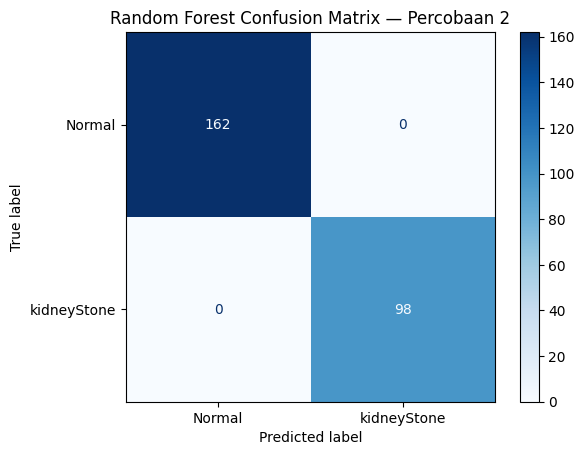

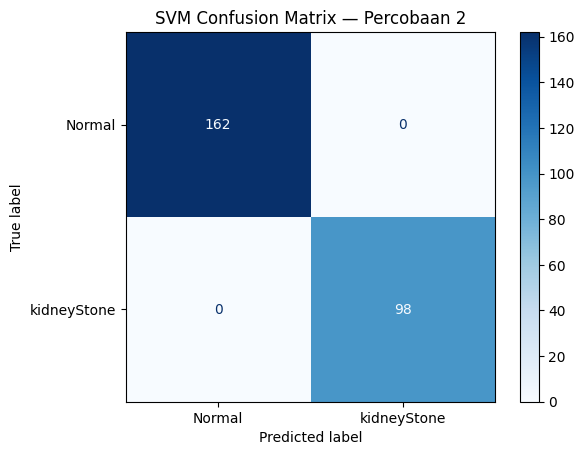

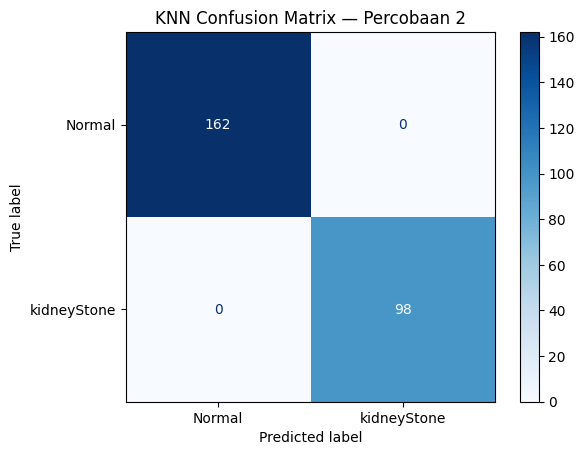

In [19]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 2')

## Ringkasan Hasil Percobaan 2

### Fungsi

Cell ini menampilkan ringkasan hasil eksperimen pada preprocessing kedua, meliputi metode preprocessing yang digunakan, jumlah fitur hasil seleksi, serta performa masing-masing algoritma klasifikasi pada data testing.

Ringkasan ini digunakan untuk mengevaluasi pengaruh penambahan Median Filter dan Histogram Equalization terhadap kualitas fitur tekstur GLCM serta performa klasifikasi yang dihasilkan.

### Hasil Percobaan

**Metode Preprocessing:**
- Resize (256×256)
- Grayscale
- Median Filter
- Histogram Equalization

**Jumlah fitur setelah seleksi:**
- 10 fitur

**Akurasi Data Testing:**

| Algoritma | Accuracy |
|------------|------------|
| Random Forest | 100% |
| SVM | 100% |
| KNN | 100% |

### Analisis

Berdasarkan hasil pengujian, seluruh algoritma klasifikasi berhasil mencapai nilai Accuracy sebesar 100% pada data testing.

Hasil ini menunjukkan bahwa preprocessing kedua mampu menghasilkan fitur tekstur yang sangat baik untuk membedakan citra ginjal Normal dan Kidney Stone. Penambahan Median Filter membantu mengurangi noise pada citra, sedangkan Histogram Equalization meningkatkan kontras sehingga pola tekstur menjadi lebih jelas sebelum proses ekstraksi fitur dilakukan.

Meskipun jumlah fitur yang digunakan setelah seleksi tetap sebanyak 10 fitur seperti pada percobaan pertama, kualitas representasi fitur yang dihasilkan menjadi lebih baik karena berasal dari citra yang telah mengalami perbaikan kualitas.

Keberhasilan Random Forest, SVM, dan KNN mencapai akurasi 100% menunjukkan bahwa fitur GLCM yang dihasilkan memiliki tingkat separabilitas yang sangat tinggi sehingga ketiga algoritma mampu membedakan kedua kelas tanpa kesalahan klasifikasi pada data testing.

Menariknya, performa sempurna ini diperoleh meskipun pengujian dilakukan pada 260 data testing, yang jumlahnya lebih besar dibandingkan percobaan pertama. Hal ini menunjukkan bahwa hasil klasifikasi yang diperoleh cukup konsisten dan mampu dipertahankan pada jumlah data uji yang lebih banyak.

Karena seluruh algoritma menghasilkan performa yang sama, tidak terdapat algoritma yang secara signifikan lebih unggul pada percobaan kedua. Oleh karena itu, hasil ini menunjukkan bahwa kombinasi Median Filter dan Histogram Equalization berhasil menghasilkan fitur tekstur yang sangat representatif untuk proses klasifikasi citra ginjal.

Ringkasan hasil percobaan kedua ini selanjutnya digunakan sebagai dasar perbandingan dengan preprocessing lainnya untuk mengetahui apakah teknik peningkatan kualitas citra yang berbeda mampu menghasilkan efisiensi fitur atau performa klasifikasi yang lebih baik.

In [20]:
print('=== RINGKASAN HASIL PERCOBAAN 2 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale + Median Filter + Histogram Equalization')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 2 ===
Preprocessing: Resize (256x256) + Grayscale + Median Filter + Histogram Equalization
Jumlah Fitur Setelah Seleksi: 10

Akurasi Testing Set:
  Random Forest : 1.0000
  SVM           : 1.0000
  KNN           : 1.0000
